# TD3 baseline on Four Rooms

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))

from utils import TrajectoryReplayBuffer, collect_episode, evaluate_policy
from visualisations import plot_policy_rollouts, plot_q_diagnostics
from networks import TD3_Critic
from agents import TD3_Actor
from benchmarks.factory import make_env, load_dataset_into_buffer

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: mps


In [2]:
def make_pointmaze_env(render_mode=None):
    return make_env(
        benchmark="ogbench",
        task="pointmaze-medium-navigate-v0",
        seed=0,
        add_goal_wrapper=False,
        render_mode=render_mode,
    )
env = make_pointmaze_env()
print("OGBench obs dim:", env.observation_space.shape[0])
print("OGBench act dim:", env.action_space.shape[0])
env.close()

OGBench obs dim: 2
OGBench act dim: 2


OGBench env shapes: obs_dim=2, act_dim=2


pointmaze-medium-navigate-v0.npz: 100%|██████████| 19.3M/19.3M [00:02<00:00, 9.13MB/s]


pointmaze-medium-navigate-v0-val.npz: 100%|██████████| 1.93M/1.93M [00:00<00:00, 2.32MB/s]


Loaded OGBench episodes: 1000
[TD3-offline OGBench] grad_step=   3000 | critic_loss=0.0008 | actor_loss=0.4173 | mean_q=-0.4281 | mean|a|=0.9492
[TD3-offline OGBench] grad_step=   6000 | critic_loss=0.0011 | actor_loss=0.3511 | mean_q=-0.3560 | mean|a|=0.9548
[TD3-offline OGBench] grad_step=   9000 | critic_loss=0.0005 | actor_loss=0.3338 | mean_q=-0.3416 | mean|a|=0.9687
[TD3-offline OGBench] grad_step=  12000 | critic_loss=0.0002 | actor_loss=0.3189 | mean_q=-0.3254 | mean|a|=0.9836
[TD3-offline OGBench] grad_step=  15000 | critic_loss=0.0010 | actor_loss=0.2633 | mean_q=-0.2697 | mean|a|=0.9770
[TD3-offline OGBench] grad_step=  18000 | critic_loss=0.0016 | actor_loss=0.2529 | mean_q=-0.2586 | mean|a|=0.9459
[TD3-offline OGBench] grad_step=  21000 | critic_loss=0.0000 | actor_loss=0.2267 | mean_q=-0.2313 | mean|a|=0.9811
[TD3-offline OGBench] grad_step=  24000 | critic_loss=0.0001 | actor_loss=0.1911 | mean_q=-0.1963 | mean|a|=0.9784
[TD3-offline OGBench] grad_step=  27000 | critic_l

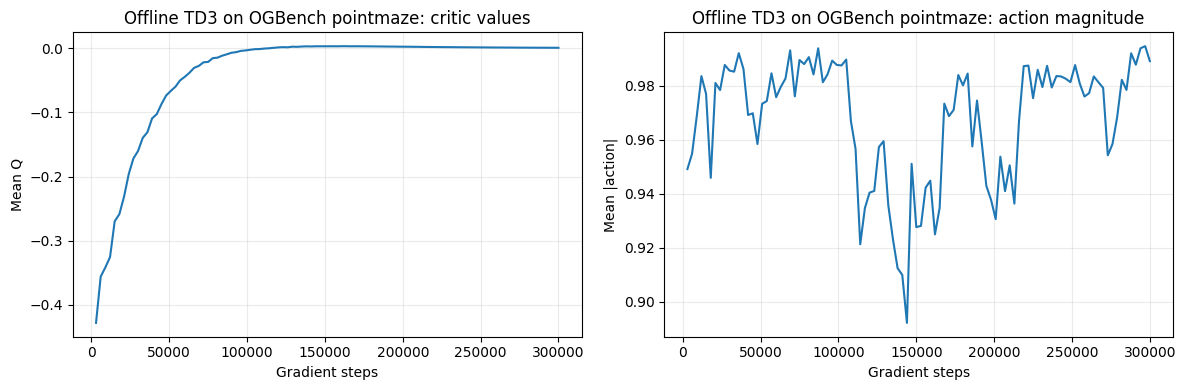

In [3]:


def td3_train_offline_ogbench(
    dataset_name="pointmaze-medium-navigate-v0",
    total_gradient_steps=300000,
    batch_size=256,
    gamma=0.99,
    tau=0.005,
    policy_noise=0.2,
    noise_clip=0.5,
    policy_delay=4,
    lr=3e-4,
    replay_capacity=2_000_000,
    eval_every=3000,
    eval_episodes=8,
    max_episodes=None,
):
    # 1) Create OGBench pointmaze env for shapes and later evaluation
    env = make_pointmaze_env()
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.shape[0]
    print(f"OGBench env shapes: obs_dim={obs_dim}, act_dim={act_dim}")

    # 2) Build TD3 networks
    actor = TD3_Actor(obs_dim, act_dim).to(DEVICE)
    actor_tgt = TD3_Actor(obs_dim, act_dim).to(DEVICE)
    actor_tgt.load_state_dict(actor.state_dict())

    q1 = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q2 = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q1_tgt = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q2_tgt = TD3_Critic(obs_dim, act_dim).to(DEVICE)
    q1_tgt.load_state_dict(q1.state_dict())
    q2_tgt.load_state_dict(q2.state_dict())

    actor_opt = optim.Adam(actor.parameters(), lr=lr)
    critic_opt = optim.Adam(list(q1.parameters()) + list(q2.parameters()), lr=lr)

    # 3) Replay buffer
    replay = TrajectoryReplayBuffer(
        capacity=replay_capacity,
        obs_dim=obs_dim,
        action_dim=act_dim,
        device=DEVICE,
    )

    # 4) Load OGBench offline dataset into replay
    num_loaded = load_dataset_into_buffer(
        benchmark="ogbench",
        replay_buffer=replay,
        task=dataset_name,
        data_root=None,
        algorithm=None,      # not used for ogbench branch
        split="train",
        max_episodes=max_episodes,
        auto_download=True,
    )
    print("Loaded OGBench episodes:", num_loaded)

    eval_log = []

    # 5) Offline TD3 updates
    for train_it in range(1, total_gradient_steps + 1):
        batch = replay.sample(batch_size)

        obs = batch.obs.float()
        act = batch.actions.float()
        rew = batch.rewards.float()
        next_obs = batch.next_obs.float()
        done = torch.clamp(batch.terminated + batch.truncated, 0, 1).float()

        with torch.no_grad():
            noise = torch.randn_like(act) * policy_noise
            noise = torch.clamp(noise, -noise_clip, noise_clip)
            next_a = torch.clamp(actor_tgt(next_obs) + noise, -1.0, 1.0)
            target_q = torch.min(q1_tgt(next_obs, next_a), q2_tgt(next_obs, next_a))
            y = rew + gamma * (1.0 - done) * target_q

        critic_loss = F.mse_loss(q1(obs, act), y) + F.mse_loss(q2(obs, act), y)
        critic_opt.zero_grad()
        critic_loss.backward()
        critic_opt.step()

        actor_loss_val = np.nan

        if train_it % policy_delay == 0:
            actor_loss = -q1(obs, actor(obs)).mean()
            actor_opt.zero_grad()
            actor_loss.backward()
            actor_opt.step()
            actor_loss_val = float(actor_loss.item())

            with torch.no_grad():
                for p, pt in zip(actor.parameters(), actor_tgt.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)
                for p, pt in zip(q1.parameters(), q1_tgt.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)
                for p, pt in zip(q2.parameters(), q2_tgt.parameters()):
                    pt.data.mul_(1 - tau).add_(tau * p.data)

        if train_it % eval_every == 0:
            # quick diagnostic: mean Q and mean |a|
            with torch.no_grad():
                mean_q = float(q1(obs, act).mean().item())
                mean_abs_action = float(actor(obs).abs().mean().item())
            eval_log.append((train_it, mean_q, mean_abs_action))
            print(
                f"[TD3-offline OGBench] grad_step={train_it:7d} | "
                f"critic_loss={critic_loss.item():.4f} | "
                f"actor_loss={actor_loss_val:.4f} | "
                f"mean_q={mean_q:.4f} | "
                f"mean|a|={mean_abs_action:.4f}"
            )

    env.close()
    return actor, q1, q2, eval_log


td3_actor, td3_q1, td3_q2, td3_log = td3_train_offline_ogbench(
    dataset_name="pointmaze-medium-navigate-v0",
    total_gradient_steps=300000,
    max_episodes=None,
)

if td3_log:
    xs = [x[0] for x in td3_log]
    mean_qs = [x[1] for x in td3_log]
    mean_abs_actions = [x[2] for x in td3_log]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(xs, mean_qs)
    axes[0].set_xlabel("Gradient steps")
    axes[0].set_ylabel("Mean Q")
    axes[0].set_title("Offline TD3 on OGBench pointmaze: critic values")
    axes[0].grid(alpha=0.25)

    axes[1].plot(xs, mean_abs_actions)
    axes[1].set_xlabel("Gradient steps")
    axes[1].set_ylabel("Mean |action|")
    axes[1].set_title("Offline TD3 on OGBench pointmaze: action magnitude")
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()


## Visualisations

Steps: 500
Return: 0.0
Terminated: False
Truncated: False


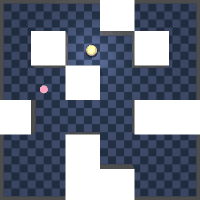

In [4]:
from benchmarks.visualise import collect_episode_frames, save_gif
from IPython.display import Image, display

eval_env = make_pointmaze_env(render_mode="rgb_array")

def td3_policy(env, obs):
    del env
    obs_t = torch.tensor(obs, dtype=torch.float32, device=DEVICE).unsqueeze(0)
    with torch.no_grad():
        return td3_actor(obs_t).squeeze(0).cpu().numpy().astype(np.float32)

rollout = collect_episode_frames(
    eval_env,
    policy_fn=td3_policy,
    max_steps=500,
)

save_gif(rollout["frames"], "td3_og_pointmaze.gif", fps=30)

print("Steps:", rollout["num_steps"])
print("Return:", rollout["total_reward"])
print("Terminated:", rollout["terminated"])
print("Truncated:", rollout["truncated"])

display(Image(filename="td3_og_pointmaze.gif"))
eval_env.close()